Reading NSRDB data from: /Users/Chiara/Documents/Documents_Chiara_MacBook_Air/Education : Personal Projects : Studies/Heat Transfer/477448_40.01_-105.26_2022.csv
  Station : lat=40.01, lon=-105.26, timezone UTC-7
  Total rows : 8760
  Columns    : ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Clearsky GHI', 'Temperature']

July means from 744 rows (31 days)
  Mean temp : -1.0 °C
  Peak GHI  : 544 W/m²

Temperature Fourier fit  (N=2):
  a0   = 272.1101 K
  a1   = -4.1494 K
  b1   = -1.0584 K
  a2   = 2.0276 K
  b2   = 0.4442 K
  RMSE = 0.3829 K

Solar GHI Fourier fit  (N=2, daylight hours only):
  a0   = -57.5595 W/m²
  a1   = -485.7061 W/m²
  b1   = -14.7144 W/m²
  a2   = 120.8397 W/m²
  b2   = 16.1622 W/m²
  RMSE (daylight) = 2.3698 W/m²

Parameters saved to: /Users/Chiara/Documents/Documents_Chiara_MacBook_Air/Education : Personal Projects : Studies/Heat Transfer/july_params.json


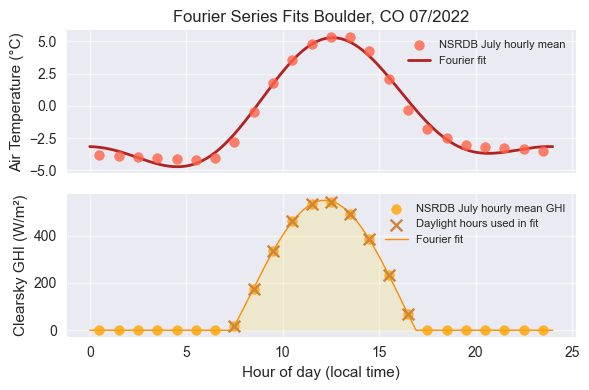

Diagnostic plot saved to: /Users/Chiara/Documents/Documents_Chiara_MacBook_Air/Education : Personal Projects : Studies/Heat Transfer/diurnal_fit_july.png

All done. Run wall_simulation.py next.


In [ ]:
import csv
import glob
import io
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION
# =============================================================================
OUT_DIR = "/Users/Chiara/Documents/Documents_Chiara_MacBook_Air/Education : Personal Projects : Studies/Heat Transfer"
MONTH   = 1       # July
N_HARM  = 2       # number of Fourier harmonics
T_PER   = 86400.0 # period [s]

# =============================================================================
# STEP 1 — LOAD DATA FROM LOCAL NSRDB CSV FILE
# =============================================================================
csv_matches = glob.glob(os.path.join(OUT_DIR, "*.csv"))
assert len(csv_matches) >= 1, (
    f"No CSV files found in:\n  {OUT_DIR}\n"
    "Download from https://nsrdb.nrel.gov/data-viewer and save there."
)
csv_path = csv_matches[0]
print(f"Reading NSRDB data from: {csv_path}")

with open(csv_path, "r") as f:
    lines = f.read().splitlines()

# NSRDB layout: row 0 = meta keys, row 1 = meta vals,
#               row 2 = column headers, row 3+ = data
meta  = dict(zip(lines[0].split(","), lines[1].split(",")))
print(f"  Station : lat={meta.get('Latitude')}, lon={meta.get('Longitude')}, "
      f"timezone UTC{meta.get('Local Time Zone')}")

reader = csv.DictReader(io.StringIO("\n".join(lines[2:])))
rows   = list(reader)
print(f"  Total rows : {len(rows)}")

# Print column names so you can verify them
print(f"  Columns    : {list(rows[0].keys())}")

months  = np.array([int(r["Month"])              for r in rows])
hours   = np.array([int(r["Hour"])               for r in rows])
ghi     = np.array([float(r["Clearsky GHI"])     for r in rows])  # W/m²
temp_c  = np.array([float(r["Temperature"])      for r in rows])  # °C

# =============================================================================
# STEP 2 — FILTER TO JULY AND COMPUTE HOURLY MEANS
# =============================================================================
mask   = months == MONTH
h_jul  = hours[mask]
g_jul  = ghi[mask]
t_jul  = temp_c[mask]

hour_bins   = np.arange(24)
ghi_mean    = np.array([g_jul[h_jul == h].mean() for h in hour_bins])
temp_mean_c = np.array([t_jul[h_jul == h].mean() for h in hour_bins])
temp_mean_K = temp_mean_c + 273.15

# Hour-centre times in seconds
t_sec = (hour_bins + 0.5) * 3600.0

print(f"\nJuly means from {mask.sum()} rows ({mask.sum()//24} days)")
print(f"  Mean temp : {temp_mean_c.mean():.1f} °C")
print(f"  Peak GHI  : {ghi_mean.max():.0f} W/m²")

# =============================================================================
# STEP 3 — FOURIER SERIES LEAST SQUARES FIT (LINEAR)
#
# Build the design matrix A where each row corresponds to one hour:
#   A[i] = [1,
#            cos(2π·1·t/T), sin(2π·1·t/T),
#            cos(2π·2·t/T), sin(2π·2·t/T)]
#
# Then solve  A @ θ = y  in the least-squares sense via numpy.linalg.lstsq.
# Because A is full-rank and the system is square (24 equations, 5 unknowns),
# this gives the exact minimum of  sum( (f(t_i) - y_i)^2 ).
#
# Coefficients θ = [a0, a1, b1, a2, b2]
# =============================================================================
def design_matrix(t, n_harm, period):
    """Build Fourier design matrix for times t, n_harm harmonics."""
    cols = [np.ones_like(t)]
    for n in range(1, n_harm + 1):
        cols.append(np.cos(2 * np.pi * n * t / period))
        cols.append(np.sin(2 * np.pi * n * t / period))
    return np.column_stack(cols)   # shape (len(t), 1 + 2*n_harm)

def fourier_eval(t, coeffs, n_harm, period):
    """Evaluate fitted Fourier series at times t."""
    A = design_matrix(t, n_harm, period)
    return A @ coeffs

# --- Temperature fit (all 24 hours) ---
A_T        = design_matrix(t_sec, N_HARM, T_PER)
coeffs_T, res_T, _, _ = np.linalg.lstsq(A_T, temp_mean_K, rcond=None)
T_fit      = fourier_eval(t_sec, coeffs_T, N_HARM, T_PER)
T_rmse     = np.sqrt(np.mean((T_fit - temp_mean_K)**2))

print(f"\nTemperature Fourier fit  (N={N_HARM}):")
labels = ["a0"] + [f"{c}{n}" for n in range(1, N_HARM+1) for c in ("a","b")]
for lbl, c in zip(labels, coeffs_T):
    print(f"  {lbl:4s} = {c:.4f} K")
print(f"  RMSE = {T_rmse:.4f} K")

# --- Solar irradiance fit (daylight hours only, then clip at zero) ---
day_mask   = ghi_mean > 5.0
t_day      = t_sec[day_mask]
ghi_day    = ghi_mean[day_mask]

A_G        = design_matrix(t_day, N_HARM, T_PER)
coeffs_G, _, _, _ = np.linalg.lstsq(A_G, ghi_day, rcond=None)
G_fit_day  = fourier_eval(t_day, coeffs_G, N_HARM, T_PER)
G_rmse     = np.sqrt(np.mean((G_fit_day - ghi_day)**2))

# Evaluate on all 24 hours for plotting (clip negatives)
G_fit_all  = np.maximum(fourier_eval(t_sec, coeffs_G, N_HARM, T_PER), 0.0)

print(f"\nSolar GHI Fourier fit  (N={N_HARM}, daylight hours only):")
for lbl, c in zip(labels, coeffs_G):
    print(f"  {lbl:4s} = {c:.4f} W/m²")
print(f"  RMSE (daylight) = {G_rmse:.4f} W/m²")

# =============================================================================
# STEP 4 — SAVE PARAMETERS TO JSON
# =============================================================================
params = {
    "month"        : MONTH,
    "n_harmonics"  : N_HARM,
    "period_s"     : T_PER,
    "csv_source"   : os.path.basename(csv_path),
    "location"     : {
        "name" : "Boulder, CO",
        "lat"  : float(meta.get("Latitude",  40.015)),
        "lon"  : float(meta.get("Longitude", -105.27))
    },
    "temperature"  : {
        "coeffs"  : coeffs_T.tolist(),   # [a0, a1, b1, a2, b2]  in Kelvin
        "rmse_K"  : float(T_rmse)
    },
    "solar"        : {
        "coeffs"       : coeffs_G.tolist(),  # [a0, a1, b1, a2, b2]  in W/m²
        "rmse_Wm2"     : float(G_rmse),
        "fit_note"     : "fitted on daylight hours only; clip to 0 at night"
    }
}

json_path = os.path.join(OUT_DIR, "july_params.json")
with open(json_path, "w") as f:
    json.dump(params, f, indent=2)
print(f"\nParameters saved to: {json_path}")

# =============================================================================
# STEP 5 — DIAGNOSTIC PLOT
# =============================================================================
t_fine    = np.linspace(0, 86400, 2000)
T_fine    = fourier_eval(t_fine, coeffs_T, N_HARM, T_PER) - 273.15
G_fine    = np.maximum(fourier_eval(t_fine, coeffs_G, N_HARM, T_PER), 0.0)

plt.style.use("seaborn-v0_8")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

# --- Temperature ---
ax1.scatter(t_sec/3600, temp_mean_K - 273.15, color='tomato', s=50, zorder=5, label="NSRDB July hourly mean", alpha = 0.8)
ax1.plot(t_fine/3600, T_fine, color='firebrick', lw=2,
         label=f"Fourier fit")
ax1.set_ylabel("Air Temperature (°C)")
ax1.set_title(f"Fourier Series Fits Boulder, CO 07/2022")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.6)

# --- Solar irradiance ---
ax2.scatter(t_sec/3600, ghi_mean, color='orange', s=50, zorder=5, label="NSRDB July hourly mean GHI", alpha = 0.8)
ax2.scatter(t_sec[day_mask]/3600, ghi_mean[day_mask], color='peru', s=70, zorder=6, marker='x', label="Daylight hours used in fit")
ax2.plot(t_fine/3600, G_fine, color='darkorange', lw=1, label=f"Fourier fit")
ax2.fill_between(t_fine/3600, G_fine, 0, alpha=0.15, color='gold')
ax2.set_ylabel("Clearsky GHI (W/m²)")
ax2.set_xlabel("Hour of day (local time)")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.6)

fig.tight_layout()
plot_path = os.path.join(OUT_DIR, "diurnal_fit.png")
fig.savefig(plot_path, dpi=300, facecolor="white")
plt.show()
print(f"Diagnostic plot saved to: {plot_path}")
print("\nAll done. Run wall_simulation.py next.")